In [ ]:
# import all the packages

import pandas as pd
import re
from sklearn.model_selection import train_test_split


In [ ]:
## 1) READING AND PROCESSING DATA:

##

In [ ]:
# This is for swepat_1885_1914, closer to 19th c. classes?

df = pd.read_csv("swepat_1885_1914.csv", encoding="utf-8")


In [ ]:
# quick and dirty normalisation of the patent titles to modern Swedish:

def normalize_1800s_swedish(text):
    rules = [
        (r'\bhv', 'v'),
        (r'\bfv', 'v'),
        (r'qv', 'kv'),
        (r'fv', 'v'),
        (r'dt\b', 't'),
        (r'(?<=\w)w', 'v'),
        (r'th', 't'),
        (r'\baf\b', 'av'),
        (r'\baf(?=[a-zåäö])', 'av'),
        (r'öf', 'öv'),
        (r'jern', 'järn'),
        (r'jem', 'jäm'),
        (r'\bder\b', 'där'),
        (r'dertil', 'därtill'),
        (r'\bellr\b', 'eller'),
        (r'sjelf', 'själv'),
        (r'svafvel', 'svavel'),
        (r'skruf', 'skruv'),
        (r'väf', 'väv'),
        (r'\s+', ' ')
    ]
    for pattern, repl in rules:
        text = re.sub(pattern, repl, text, flags=re.IGNORECASE)
    return text

df["patent_title_norm"] = df["patent_title"].astype(str).apply(normalize_1800s_swedish)


In [ ]:
# This is for testing without normalisation

df["patent_title_norm"] = df["patent_title"]

In [ ]:
## THIS IS TO CHECK EMBEDDING SIMILARITIES BETWEEN TITLE AND NORMALISED

import torch
import numpy as np
import pandas as pd
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm

# -----------------------------
# 1. Load KB-BERT
# -----------------------------
tokenizer = AutoTokenizer.from_pretrained("KB/bert-base-swedish-cased")
model = AutoModel.from_pretrained("KB/bert-base-swedish-cased")
model.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# -----------------------------
# 2. Mean pooling function
# -----------------------------
def mean_pooling(model_output, attention_mask):
    token_embeddings = model_output.last_hidden_state
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    return torch.sum(token_embeddings * input_mask_expanded, 1) / torch.clamp(input_mask_expanded.sum(1), min=1e-9)

# -----------------------------
# 3. Encoding function
# -----------------------------
def encode(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=64,
        padding=True
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    emb = mean_pooling(outputs, inputs["attention_mask"])
    return emb.cpu().numpy()

# -----------------------------
# 4. Compute similarities
# -----------------------------
similarities = []

for orig, norm in tqdm(zip(df["patent_title"], df["patent_title_norm"]), total=len(df)):
    v1 = encode(str(orig))
    v2 = encode(str(norm))
    sim = cosine_similarity(v1, v2)[0][0]
    similarities.append(sim)

df["title_embedding_similarity"] = similarities

# -----------------------------
# 5. Inspect results
# -----------------------------
print("\n=== Similarity Distribution ===")
print(df["title_embedding_similarity"].describe())

print("\n=== Most Changed Titles (Lowest Similarity) ===")
cols = ["patent_title", "patent_title_norm", "title_embedding_similarity"]
print(df.sort_values("title_embedding_similarity")[cols].head(10))

print("\n=== Least Changed Titles (Highest Similarity) ===")
print(df.sort_values("title_embedding_similarity", ascending=False)[cols].head(10))


In [ ]:
df

,patent_number,patent_title,application_year,dpk,patent_title_norm
0,8339,Ställinrättning vid fjäderpinnharfvr för regle...,1896,45a,Ställinrättning vid fjäderpinnharvr för regler...
1,8616,Maskin för färdigformning af hylsämnen af läde...,1896,56a,Maskin för färdigformning av hylsämnen av läde...
2,12613,Anordning för pinnarnas fästande vid fjäderhar...,1899,45a,Anordning för pinnarnas fästande vid fjäderharvar
3,29164,Anordning vid skaklar,1909,63a,Anordning vid skaklar
4,4337,Anordning för spetsarnes fästande å harfvar me...,1892,45a,Anordning för spetsarnes fästande å harvar med...
...,...,...,...,...,...
36088,5052,Anordningar vid tjärdestillationsapparater,1893,12r,Anordningar vid tjärdestillationsapparater
36089,34382,Förfarande vid framställning av massor för kor...,1910,8L,Förfarande vid framställning av massor för kor...
36090,32640,Borrchuck,1910,49a,Borrchuck
36091,25897,Anordning vid dragstift och dylikt,1905,42a,Anordning vid dragstift och dylikt


In [ ]:
# create dpk main class and dpk full class (thus subclass) columns

import re

# Main class = numeric part
df["dpk_main"] = df["dpk"].str.extract(r"^(\d+)")
df["dpk_full"] = df["dpk"].str.replace(":", "")
df["dpk_full"] = df["dpk_full"].str.lower()


In [ ]:
# We remove rows where there is no DPK class

df = df.dropna(subset=["dpk"])

In [ ]:
# we remove rows where there is only mainclass number

df = df[~df["dpk_full"].str.fullmatch(r"\d+", na=False)]

In [ ]:
# check: print rows where dpk_full is not 1-2 digits plus letter

#for idx, val in df["dpk_full"].items():
#    if not re.fullmatch(r"\d{1,2}[a-z]", str(val)):
#        print(idx, val)

# OK!

In [ ]:
# we map the dpks to number labels
# 1a -> 1, 1b -> 2 , for training the model

unique_labels = sorted(df["dpk_main"].unique())
# unique_labels = sorted(df["dpk_full"].unique()) # This maps subclasses

label2id = {label: i for i, label in enumerate(unique_labels)}
id2label = {i: label for label, i in label2id.items()}

# print(label2id)

df["label_id"] = df["dpk_main"].map(label2id)
# df["label_id"] = df["dpk_full"].map(label2id) # This maps subclasses

In [ ]:
df

,patent_number,patent_title,application_year,dpk,patent_title_norm,dpk_main,dpk_full,label_id
0,8339,Ställinrättning vid fjäderpinnharfvr för regle...,1896,45a,Ställinrättning vid fjäderpinnharvr för regler...,45,45a,38
1,8616,Maskin för färdigformning af hylsämnen af läde...,1896,56a,Maskin för färdigformning av hylsämnen av läde...,56,56a,50
2,12613,Anordning för pinnarnas fästande vid fjäderhar...,1899,45a,Anordning för pinnarnas fästande vid fjäderharvar,45,45a,38
3,29164,Anordning vid skaklar,1909,63a,Anordning vid skaklar,63,63a,57
4,4337,Anordning för spetsarnes fästande å harfvar me...,1892,45a,Anordning för spetsarnes fästande å harvar med...,45,45a,38
...,...,...,...,...,...,...,...,...
36088,5052,Anordningar vid tjärdestillationsapparater,1893,12r,Anordningar vid tjärdestillationsapparater,12,12r,3
36089,34382,Förfarande vid framställning av massor för kor...,1910,8L,Förfarande vid framställning av massor för kor...,8,8l,73
36090,32640,Borrchuck,1910,49a,Borrchuck,49,49a,42
36091,25897,Anordning vid dragstift och dylikt,1905,42a,Anordning vid dragstift och dylikt,42,42a,35


In [ ]:
# Build the training data, the validation data, and the evaluation data

# we pick 80%, 10%, 10% accordingly

train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["dpk_main"], # we follow the distribution of dpk main classes
    random_state=0,
)

# Stratified split: validation (10%) and test (10%)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["dpk_main"], # we follow the distribution of dpk main classes
    random_state=0,
)

print('training dataset shape: ',train_df.shape)
print('validation dataset shape: ',val_df.shape)
print('test dataset shape: ',test_df.shape)




training dataset shape:  (28304, 8)
validation dataset shape:  (3538, 8)
test dataset shape:  (3538, 8)


In [ ]:
pd.set_option('display.max_colwidth', None)
print(test_df[test_df['dpk_main'] == "41"])

       patent_number  \
10680          10531   
8081            7867   

                                                                       patent_title  \
10680                                                          Vintermössa med bräm   
8081   Sätt att tillverka filtringar för axeltappar jemte sålunda framstälda ringar   

       application_year  dpk  \
10680              1899  41c   
8081               1896  41d   

                                                                  patent_title_norm  \
10680                                                          Vintermössa med bräm   
8081   Sätt att tillverka filtringar för axeltappar jämte sålunda framstälda ringar   

      dpk_main dpk_full  label_id  
10680       41      41c        34  
8081        41      41d        34  


In [ ]:
# create a Hugging Face structured dataset

from datasets import Dataset, DatasetDict

train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)
test_dataset = Dataset.from_pandas(test_df)

dataset = DatasetDict({
    "train": train_dataset,
    "validation": val_dataset,
    "test": test_dataset,
})


In [ ]:
# We tokenize the data for the model

from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("KB/bert-base-swedish-cased")

def tokenize(batch):
    return tokenizer(
        batch["patent_title_norm"],
        truncation=True,
        padding="max_length",
        max_length=64, # probably enough for patent titles (titles are 10-15 words, thus max 20-25 tokens)
    )

encoded_dataset = dataset.map(tokenize, batched=True)
encoded_dataset = encoded_dataset.remove_columns(["patent_title_norm"])   # keep only encodings + label
encoded_dataset = encoded_dataset.rename_column("label_id", "labels")
encoded_dataset.set_format("torch")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/491 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Map:   0%|          | 0/28304 [00:00<?, ? examples/s]

Map:   0%|          | 0/3538 [00:00<?, ? examples/s]

Map:   0%|          | 0/3538 [00:00<?, ? examples/s]

In [ ]:
## 2) LOADING AND RUNNING THE MODEL

##

In [ ]:
# we load the model

from transformers import AutoModelForSequenceClassification, AutoConfig

num_labels = df["dpk_main"].nunique()
# num_labels = df["dpk_full"].nunique() # This for using subclasses

# added higher dropup: early results showed that there is slight overfitting of the model;
#higher dropup: the model does not memorize so much from the training data,
#thus generalised better
config = AutoConfig.from_pretrained(
    "KB/bert-base-swedish-cased",
    hidden_dropout_prob=0.15,           # default for kb-bert is 0.1
    attention_probs_dropout_prob=0.15,  #
    classifier_dropout=0.15
)

model = AutoModelForSequenceClassification.from_pretrained(
    "KB/bert-base-swedish-cased",
    num_labels=num_labels, # we enter both the numerical IDs, and the dpk labels
    id2label=id2label,
    label2id=label2id
)


model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: KB/bert-base-swedish-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
#Training arguments:

from transformers import TrainingArguments, Trainer
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, classification_report

def c_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro")
    }

training_args = TrainingArguments(
    output_dir="./kb-bert_dpk-1885-1914",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    learning_rate=1.8e-5, # default was 2e-5; now slower update, able to generalise better
    num_train_epochs=4,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    weight_decay=0.02,
    warmup_ratio=0.1,

    report_to="none",

    fp16=True,  # for Colab GPU, speedens up
    logging_steps=100,
    save_total_limit=2,

)


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [ ]:
# train the model
from transformers import EarlyStoppingCallback

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=encoded_dataset["train"],
    eval_dataset=encoded_dataset["validation"],
    processing_class=tokenizer,
    compute_metrics=c_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)], # stops if model does not improve for 2 epochs, saves Colab resources
)


trainer.train()


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,1.657104,1.545218,0.655455,0.489313
2,1.117047,1.193535,0.734313,0.634646
3,0.760194,1.097760,0.760034,0.689826
4,0.587180,1.067926,0.768231,0.702959


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=7076, training_loss=1.349633613099076, metrics={'train_runtime': 836.5398, 'train_samples_per_second': 135.338, 'train_steps_per_second': 8.459, 'total_flos': 3726322530705408.0, 'train_loss': 1.349633613099076, 'epoch': 4.0})

In [ ]:
# print the results

results = trainer.predict(encoded_dataset["test"])

logits, labels = results.predictions, results.label_ids
results_ids = np.argmax(logits, axis=-1)

unique_labels = sorted(np.unique(labels))

print(classification_report(
    y_true = labels,
    y_pred = results_ids,
    labels = unique_labels,
    target_names=[id2label[i] for i in unique_labels]
))


## PRINT ALSO TO CSV:

report_dict = classification_report(
    y_true = labels,
    y_pred = results_ids,
    labels = unique_labels,
    target_names=[id2label[i] for i in unique_labels],
    output_dict=True
)

df_report = pd.DataFrame(report_dict).transpose()
df_report.to_csv("class_report_model3.csv", index=True)

# support == number of true samples belonging to the class in the evaluation dataset

              precision    recall  f1-score   support

           1       0.82      0.86      0.84        21
          10       0.79      0.74      0.77        31
          11       0.54      0.44      0.48        16
          12       0.74      0.80      0.77        88
          13       0.70      0.80      0.74        44
          14       0.72      0.89      0.80        46
          15       0.79      0.70      0.74        43
          17       0.72      0.76      0.74        17
          18       0.60      0.67      0.63        27
          19       0.83      0.79      0.81        24
           2       0.85      0.81      0.83        21
          20       0.90      0.82      0.86        89
          21       0.86      0.88      0.87       295
          22       0.57      0.55      0.56        22
          23       0.67      0.82      0.73        22
          24       0.69      0.66      0.67        58
          25       0.78      0.70      0.74        10
          26       0.88    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

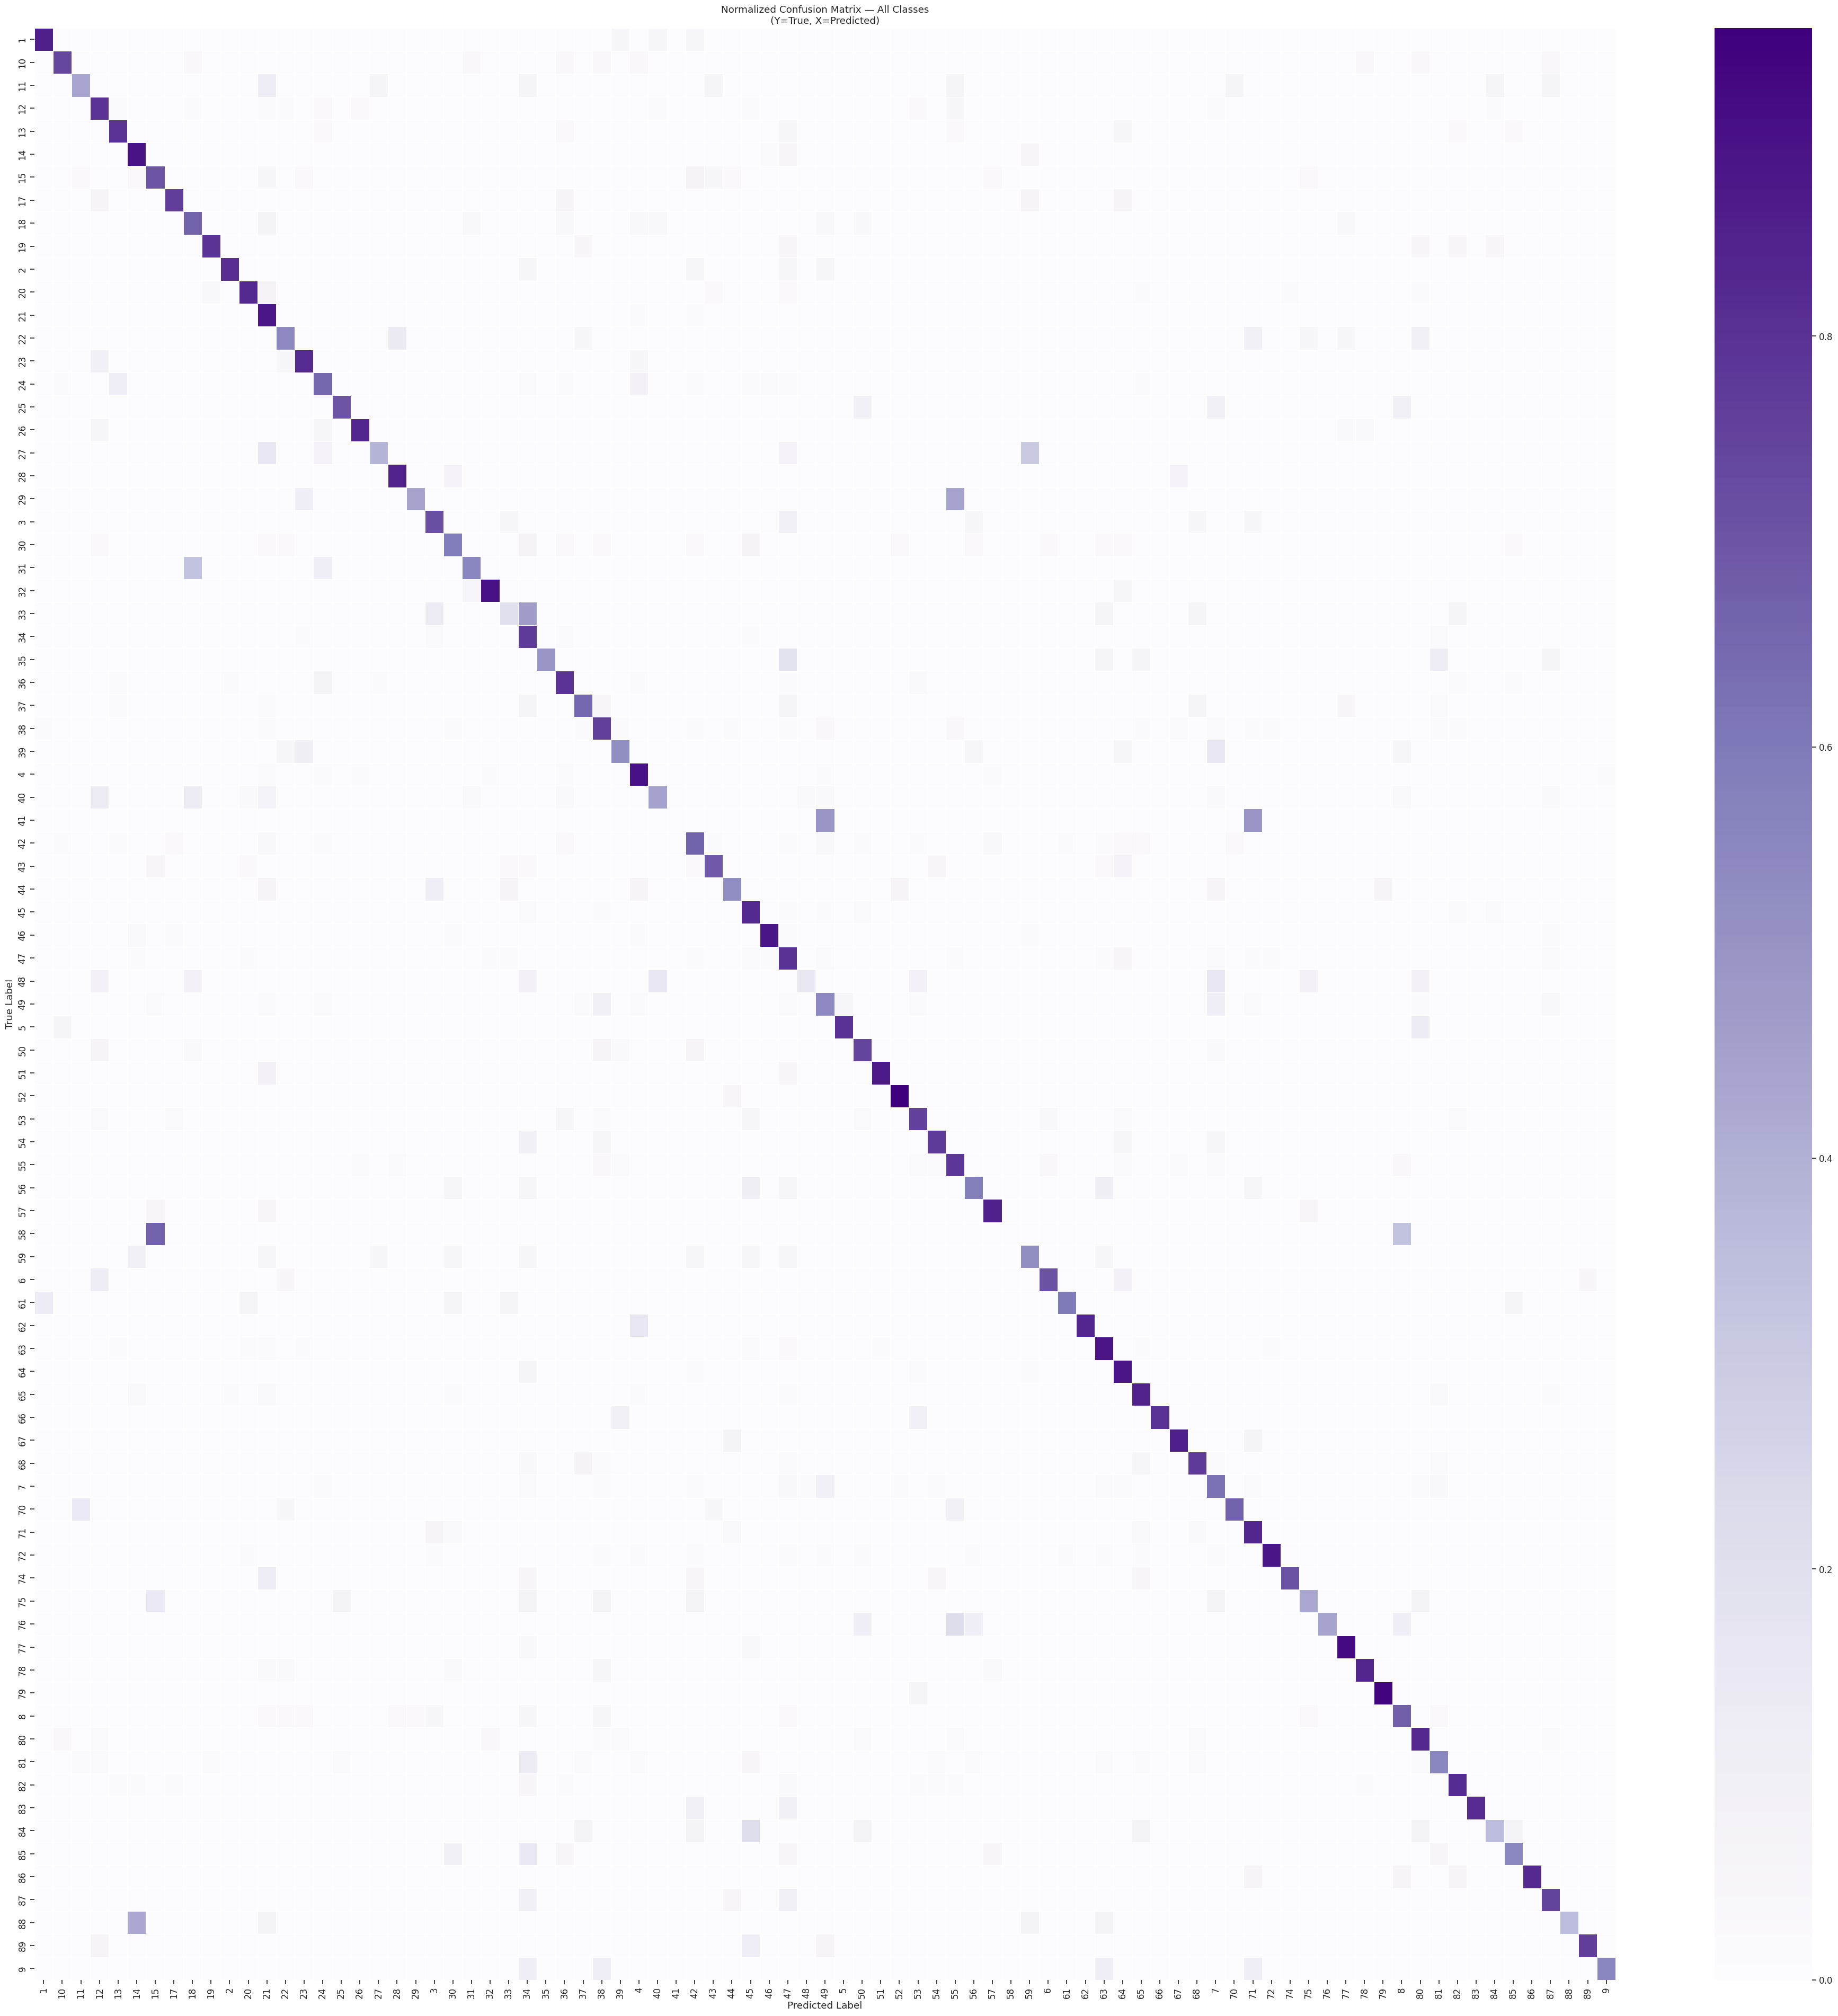

In [ ]:
# heatmap, what classes are predicted "wrong": y-axis true class, x-axis prediction

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# -----------------------------------------------------------
# 1. Get all true & predicted labels
# -----------------------------------------------------------

results = trainer.predict(encoded_dataset["test"])
logits, labels = results.predictions, results.label_ids
preds = np.argmax(logits, axis=-1)

# ensure id2label keys are integers
id2label = {int(k): v for k, v in id2label.items()}

# sorted list of all class IDs
all_classes = sorted(id2label.keys())
n_classes = len(all_classes)

# -----------------------------------------------------------
# 2. Build normalized confusion matrix
# -----------------------------------------------------------

cm = confusion_matrix(
    y_true=labels,
    y_pred=preds,
    labels=all_classes,
    normalize="true"        # <-- THIS MAKES IT ROW-NORMALIZED
)

# -----------------------------------------------------------
# 3. Convert to DataFrame and label axes
# -----------------------------------------------------------

df_cm = pd.DataFrame(
    cm,
    index=[id2label[i] for i in all_classes],     # True labels
    columns=[id2label[i] for i in all_classes]    # Predicted labels
)

# -----------------------------------------------------------
# 4. Plot heatmap
# -----------------------------------------------------------

# Automatic width scaling: ~0.45 inches per class
width = max(18, n_classes * 0.45)
height = max(16, n_classes * 0.45)

plt.figure(figsize=(width, height))

sns.set(style='ticks', font_scale=1.1)
sns.heatmap(
    df_cm,
    cmap='Purples',
    annot=False,         # set to True for numeric values
    linewidths=0.5
)

plt.title("Normalized Confusion Matrix — All Classes\n(Y=True, X=Predicted)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


['q', '##vinna']
['kvinna']


In [ ]:
df2 = pd.read_csv("zpatents_for_evaluation.csv")



In [ ]:

# we do the same normalisation

df2["patent_title_norm"] = df2["patent_title"].astype(str).apply(normalize_1800s_swedish)


In [ ]:
df2

,patent_number,patent_title,dpk,predicted_dpk,patent_title_norm
0,Z999,å en förbättring af propeller för drifvande af ångfartyg,65.0,65,å en förbättring av propeller för drivande av ångfartyg
1,Z998,å en förbättring af öfverbyggnaden på jernvägar,19.0,19,å en förbättring av överbyggnaden på järnvägar
2,Z997,"å en tryckmachin med dertill hörande torkinrättning, m. m.",15.0,15,"å en tryckmachin med därtilll hörande torkinrättning, m. m."
3,Z996,å en förbättring och förenkling af s. k. weft-motion å skedlag till mekanisk power loom,86.0,86,å en förbättring och förenkling av s. k. weft-motion å skedlag till mekanisk pover loom
4,Z995,å en uppfinning af s. k. »weftmotion » eller inslagsrörelser för mekaniska vafstolar,86.0,86,å en uppfinning av s. k. »weftmotion » eller inslagsrörelser för mekaniska vafstolar
...,...,...,...,...,...
6110,6055,"Sätt och apparat för att behandla djurben för framställning af lim, samt att medelst sur fosforsyrad kalk och sur svafvelsyrlig kalk framställa cellulosa af sågspån, trä halm och andra fibrösa ämnen",NaN,55,"Sätt och apparat för att behandla djurben för framställning av lim, samt att medelst sur fosforsyrad kalk och sur svavelsyrlig kalk framställa cellulosa av sågspån, trä halm och andra fibrösa ämnen"
6111,6641,Anorndingar vid Heberleinska friktions-snabbbromsar för jernvägståg,NaN,20,Anorndingar vid Heberleinska friktions-snabbbromsar för järnvägståg
6112,6155,Kalorifer,NaN,36,Kalorifer
6113,2654,Bakladdningsmekanism för kanoner,NaN,72,Bakladdningsmekanism för kanoner


In [ ]:
# tokenize david's data

from datasets import Dataset

new_dataset = Dataset.from_pandas(df2)

encoded_new = new_dataset.map(tokenize, batched=True)

# IMPORTANT: keep only model inputs (no labels needed)
encoded_new = encoded_new.remove_columns(
    [col for col in encoded_new.column_names
     if col not in ["input_ids", "attention_mask"]]
)

encoded_new.set_format("torch")

Map:   0%|          | 0/6115 [00:00<?, ? examples/s]

In [ ]:
# we use the model to predict classes

import numpy as np

predictions = trainer.predict(encoded_new)

logits = predictions.predictions
predicted_ids = np.argmax(logits, axis=-1)

In [ ]:
df2["bert_predicted_dpk"] = [id2label[i] for i in predicted_ids]

In [ ]:
df2

,patent_number,patent_title,dpk,predicted_dpk,patent_title_norm,bert_predicted_dpk
0,Z999,å en förbättring af propeller för drifvande af ångfartyg,65.0,65,å en förbättring av propeller för drivande av ångfartyg,65
1,Z998,å en förbättring af öfverbyggnaden på jernvägar,19.0,19,å en förbättring av överbyggnaden på järnvägar,20
2,Z997,"å en tryckmachin med dertill hörande torkinrättning, m. m.",15.0,15,"å en tryckmachin med därtilll hörande torkinrättning, m. m.",15
3,Z996,å en förbättring och förenkling af s. k. weft-motion å skedlag till mekanisk power loom,86.0,86,å en förbättring och förenkling av s. k. weft-motion å skedlag till mekanisk pover loom,49
4,Z995,å en uppfinning af s. k. »weftmotion » eller inslagsrörelser för mekaniska vafstolar,86.0,86,å en uppfinning av s. k. »weftmotion » eller inslagsrörelser för mekaniska vafstolar,63
...,...,...,...,...,...,...
6110,6055,"Sätt och apparat för att behandla djurben för framställning af lim, samt att medelst sur fosforsyrad kalk och sur svafvelsyrlig kalk framställa cellulosa af sågspån, trä halm och andra fibrösa ämnen",NaN,55,"Sätt och apparat för att behandla djurben för framställning av lim, samt att medelst sur fosforsyrad kalk och sur svavelsyrlig kalk framställa cellulosa av sågspån, trä halm och andra fibrösa ämnen",55
6111,6641,Anorndingar vid Heberleinska friktions-snabbbromsar för jernvägståg,NaN,20,Anorndingar vid Heberleinska friktions-snabbbromsar för järnvägståg,20
6112,6155,Kalorifer,NaN,36,Kalorifer,82
6113,2654,Bakladdningsmekanism för kanoner,NaN,72,Bakladdningsmekanism för kanoner,72


In [ ]:
df2.to_csv("zpatents_with_kb-bert.csv", index=False)

In [ ]:
# this is needed because currently the dpks are with decimals

df2["dpk_str"] = (
    pd.to_numeric(df2["dpk"], errors="coerce")
      .apply(lambda x: str(int(x)) if pd.notna(x) else pd.NA)
)


In [ ]:
df2

,patent_number,patent_title,dpk,predicted_dpk,patent_title_norm,bert_predicted_dpk,dpk_str
0,Z999,å en förbättring af propeller för drifvande af ångfartyg,65.0,65,å en förbättring av propeller för drivande av ångfartyg,65,65
1,Z998,å en förbättring af öfverbyggnaden på jernvägar,19.0,19,å en förbättring av överbyggnaden på järnvägar,20,19
2,Z997,"å en tryckmachin med dertill hörande torkinrättning, m. m.",15.0,15,"å en tryckmachin med därtilll hörande torkinrättning, m. m.",15,15
3,Z996,å en förbättring och förenkling af s. k. weft-motion å skedlag till mekanisk power loom,86.0,86,å en förbättring och förenkling av s. k. weft-motion å skedlag till mekanisk pover loom,49,86
4,Z995,å en uppfinning af s. k. »weftmotion » eller inslagsrörelser för mekaniska vafstolar,86.0,86,å en uppfinning av s. k. »weftmotion » eller inslagsrörelser för mekaniska vafstolar,63,86
...,...,...,...,...,...,...,...
6110,6055,"Sätt och apparat för att behandla djurben för framställning af lim, samt att medelst sur fosforsyrad kalk och sur svafvelsyrlig kalk framställa cellulosa af sågspån, trä halm och andra fibrösa ämnen",NaN,55,"Sätt och apparat för att behandla djurben för framställning av lim, samt att medelst sur fosforsyrad kalk och sur svavelsyrlig kalk framställa cellulosa av sågspån, trä halm och andra fibrösa ämnen",55,<NA>
6111,6641,Anorndingar vid Heberleinska friktions-snabbbromsar för jernvägståg,NaN,20,Anorndingar vid Heberleinska friktions-snabbbromsar för järnvägståg,20,<NA>
6112,6155,Kalorifer,NaN,36,Kalorifer,82,<NA>
6113,2654,Bakladdningsmekanism för kanoner,NaN,72,Bakladdningsmekanism för kanoner,72,<NA>


In [ ]:
from sklearn.metrics import classification_report

df2_eval = df2[
    df2["dpk_str"].notna() &
    df2["bert_predicted_dpk"].notna()
]

print(classification_report(
    y_true=df2_eval["dpk_str"],
    y_pred=df2_eval["bert_predicted_dpk"].astype(str)
))

              precision    recall  f1-score   support

           1       0.56      0.15      0.24        33
          10       0.64      0.60      0.62        80
          11       0.83      0.71      0.77         7
          12       0.53      0.65      0.58        94
          13       0.79      0.71      0.75        84
          14       0.49      0.69      0.57        81
          15       0.49      0.75      0.59        36
          16       0.00      0.00      0.00        21
          17       0.83      0.42      0.56        45
          18       0.82      0.62      0.70       169
          19       0.67      0.46      0.54        68
           2       0.69      0.79      0.73        28
          20       0.56      0.72      0.63       120
          21       0.45      0.90      0.60       183
          22       0.58      0.30      0.39        71
          23       0.78      0.62      0.69        68
          24       0.43      0.73      0.54        81
          25       0.83    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
## VISUALIZATION

report = classification_report(
    y_true=df2_eval["dpk_str"],
    y_pred=df2_eval["bert_predicted_dpk"].astype(str),
    output_dict=True
)

df_report = (
    pd.DataFrame(report)
      .transpose()
      .reset_index()
      .rename(columns={"index": "dpk"})
)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
df_report = df_report[
    ~df_report["dpk"].isin(["accuracy", "macro avg", "weighted avg"])
]

In [ ]:
for col in ["precision", "recall", "f1-score", "support"]:
    df_report[col] = pd.to_numeric(df_report[col], errors="coerce")

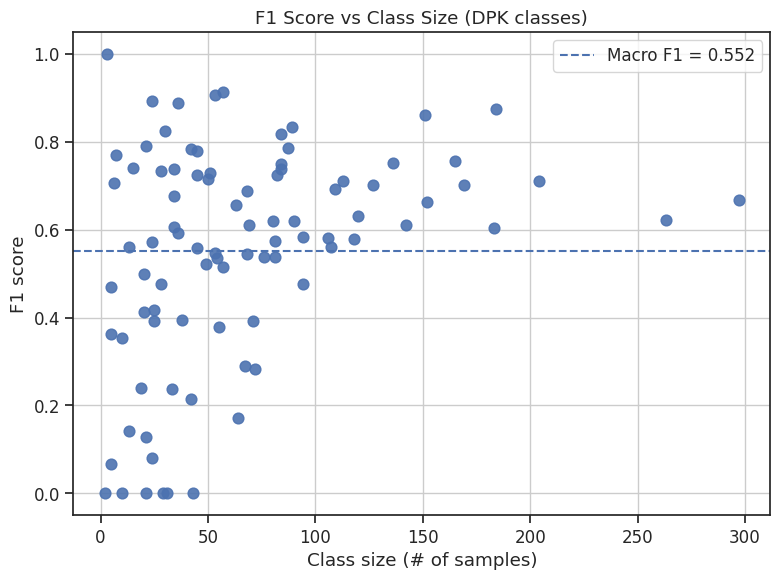

In [ ]:
import matplotlib.pyplot as plt

x = df_report["support"]
y = df_report["f1-score"]

macro_f1 = y.mean()

plt.figure(figsize=(8, 6))

plt.scatter(
    x,
    y,
    s=60,
#    color="royalblue",
    alpha=0.9
)

plt.axhline(
    macro_f1,
    linestyle="--",
    label=f"Macro F1 = {macro_f1:.3f}"
)

plt.xlabel("Class size (# of samples)")
plt.ylabel("F1 score")
plt.title("F1 Score vs Class Size (DPK classes)")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
df_31 = df2_eval[df2_eval["dpk_str"] == "31"].copy()

print(f"Number of gold class 31 samples: {len(df_31)}")

pred_counts = (
    df_31["bert_predicted_dpk"]
    .astype(str)
    .value_counts()
    .sort_index()
)

print(pred_counts)



Number of gold class 31 samples: 43
bert_predicted_dpk
12     1
14     1
15     1
18     9
20     1
21     4
40     1
47     1
48     2
49     7
7     11
80     4
Name: count, dtype: int64


In [ ]:
df_31_errors = df_31[
    df_31["bert_predicted_dpk"].astype(str) != "31"
]

df_31_errors_view = df_31_errors[
    ["patent_title_norm", "dpk_str", "bert_predicted_dpk"]
].sort_values("bert_predicted_dpk")

df_31_errors_view.head(100)

,patent_title_norm,dpk_str,bert_predicted_dpk
5635,å retortugnar för distillation av tjäruved m. m.,31,12
5798,å ett sått. att medelst tillgodogörande av centrifugalkraftens verkningar gjuta ihåliga cylindrar av järn,31,14
1077,å framstält sätt att vid gjutning i allmänhet samt specielt vid gjutning av typerföröka varaktigheten av de begagnade matricerna och patricerna.,31,15
4345,å framstälda förbättringar av kupolugnar.,31,18
3602,å flamugnar av framställd beskaffenhet för smältningar vidkoppar- bly- och nickelverk.,31,18
4568,"å ett slag av ugnar för smältning av stål i deglar, medelst användande av cokes eller träkol och upphettad luft",31,18
4576,å vissa förbättringar å ugnar för smältning av metaller och malmer,31,18
4860,å angifna satt att använda gaser från stångjärnshärd för tillvärmning av smältstycken,31,18
5833,å en förändring i konstruktionen av kupolugnar för gjuterier,31,18
5389,å ett sätt att bibringa av tackjärn gjutne artiklar ett härdfärskat järns egenskaper,31,18


In [ ]:
print("wake up")

wake up


In [ ]:
df_31 = df2_eval[df2_eval["dpk_str"] == "31"].copy()

print(f"Number of gold class 31 samples: {len(df_31)}")

pred_counts = (
    df_31["bert_predicted_dpk"]
    .astype(str)
    .value_counts()
    .sort_index()
)

print(pred_counts)


df_31_errors = df_31[
    df_31["bert_predicted_dpk"].astype(str) != "31"
]

df_31_errors_view = df_31_errors[
    ["patent_title_norm", "dpk_str", "bert_predicted_dpk"]
].sort_values("bert_predicted_dpk")

df_31_errors_view.head(50)

In [ ]:
#train_dataset = Dataset.from_pandas(train_df)
df_train_31 = train_df[train_df['dpk_main'] == "31"].copy()

pd.set_option('display.max_rows', 100)
df_train_31.head(100)

,patent_number,patent_title,application_year,dpk,patent_title_norm,dpk_main,dpk_full,label_id
11492,11359,Schaktugn,1899,31a,Schaktugn,31,31a,23
33494,33544,Schaktugn med skilda bränsle- och malmschakt,1910,31a,Schaktugn med skilda bränsle- och malmschakt,31,31a,23
27430,27429,Förfaringssätt och ugn för smältning,1907,31a,Förfaringssätt och ugn för smältning,31,31a,23
33972,34033,Uppsättningsmål,1911,31a,Uppsättningsmål,31,31a,23
11548,11415,Beskickningsapparat för schaktugnar,1898,31a,Beskickningsapparat för schaktugnar,31,31a,23
16618,16529,Sätt att infodra kärl för metallurgiska ändamål,1902,31a,Sätt att infodra kärl för metallurgiska ändamål,31,31a,23
24059,24037,Fästanordning för rostugnsarmar,1906,31a,Fästanordning för rostugnsarmar,31,31a,23
31975,32010,Slang eller rör med metallinlägg,1910,31a,Slang eller rör med metallinlägg,31,31a,23
18054,17978,Anordningar vid schaktugnar,1903,31a,Anordningar vid schaktugnar,31,31a,23
29447,29461,Sätt och anordningar för utnyttjande af de från ringugnar? Bortgående gaserna,1908,31a,Sätt och anordningar för utnyttjande av de från ringugnar? Bortgående gaserna,31,31a,23
